# Image Classification with CNN
## A deep learning approach to 10-class animal detection


For this project, I chose a dataset of 28,000 medium-quality animal images belonging to ten categories: dog, cat, horse, spider, butterfly, chicken, sheep, cow, squirrel, elephant.
The aim of the project was to create a CNN that would accept an image as input and accurately classify it into one of the ten categories.




## 1. Load, process, and validate data

### 1.1 Imports

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import models, layers

### 1.2 Load data and create training and validation sets

In [20]:
data_dir = "data"

data_kwargs = {
    "directory": data_dir,
    "validation_split": 0.2,
    "seed": 123,
    "image_size": (224, 224),
    "batch_size": 32,
    "crop_to_aspect_ratio": True,
}

# Create training set (80% of the data)
train_ds = tf.keras.utils.image_dataset_from_directory(
    **data_kwargs,
    subset="training"
)
# Save the names of the classes for later use
class_names = train_ds.class_names

# Create validation set (20% of the data)
val_ds = tf.keras.utils.image_dataset_from_directory(
    **data_kwargs,
    subset="validation"
)

Found 26179 files belonging to 10 classes.
Using 20944 files for training.
Found 26179 files belonging to 10 classes.
Using 5235 files for validation.


### 1.3 Validate data

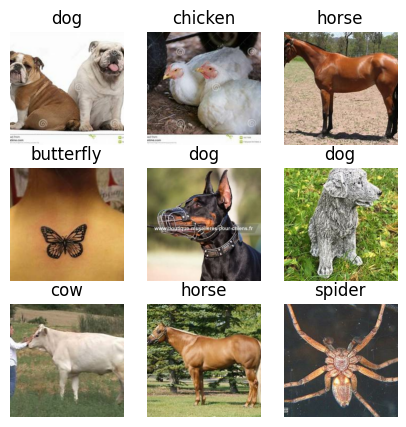

In [12]:
# Show a few images from the set to visually validate the data
for images, labels in train_ds.take(1):
    plt.figure(figsize=(5, 5))

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

    plt.show()

In [13]:
# Count the occurences of each label
labels = np.concatenate([y for x, y in train_ds], axis=0)
label_counts = np.bincount(labels)

for name, count in zip(class_names, label_counts):
    print(f"{name:20} : {count}")

butterfly            : 1723
cat                  : 1345
chicken              : 2476
cow                  : 1484
dog                  : 3915
elephant             : 1152
horse                : 2087
sheep                : 1438
spider               : 3842
squirrel             : 1482


We notice that our dataset is unbalanced - our 'dog' and 'spider' classes have almost three times as many examples as our 'elephant' class.

### 1.4 Account for unbalanced classes

In [14]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)
# To be passed when fitting the model
class_weight_dict = dict(enumerate(class_weights))

### 1.5 Normalize the input

In [21]:
def normalize_img(image, label):
    '''Function scales pixels to [0, 1]'''
    return tf.cast(image, tf.float32) / 255.0, label

# Apply function to training and validation datasets
train_ds = train_ds.map(normalize_img)
val_ds = val_ds.map(normalize_img)

## 2. Model Architecture

## 2.1 Create the model

In [16]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomContrast(0.1),

    # Block 1 - 32 filters
    layers.Conv2D(32, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 2 - 64 filters
    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3 - 128 filters
    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),


    # Block 4 - 256 filters
    layers.Conv2D(256, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Block 5 - 256 filters
    layers.Conv2D(256, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### 2.2 Early stopping to prevent overfitting

In [11]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

### 2.3 Reduce learning rate if the model doesn't improve


In [12]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7
)

### 2.4 Train the model

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr]
)
model.save("animal_classifier.keras")

Epoch 1/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 115s 157ms/step - accuracy: 0.2107 - loss: 2.4125 - val_accuracy: 0.3568 - val_loss: 1.8796 - learning_rate: 0.0010
Epoch 2/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 103s 158ms/step - accuracy: 0.4158 - loss: 1.6364 - val_accuracy: 0.4061 - val_loss: 1.6740 - learning_rate: 0.0010
Epoch 3/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 102s 156ms/step - accuracy: 0.5181 - loss: 1.3765 - val_accuracy: 0.4466 - val_loss: 1.6109 - learning_rate: 0.0010
Epoch 4/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 102s 155ms/step - accuracy: 0.5661 - loss: 1.2320 - val_accuracy: 0.5471 - val_loss: 1.3140 - learning_rate: 0.0010
Epoch 5/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 106s 161ms/step - accuracy: 0.6179 - loss: 1.1152 - val_accuracy: 0.2304 - val_loss: 2.9481 - learning_rate: 0.0010
Epoch 6/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 101s 155ms/step - accuracy: 0.6520 - loss: 1.0049 - val_accuracy: 0.5893 - val_loss: 1.1495 - learning_rate: 0.0010
Epoch 7/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 144s 157ms/step - accura

## 3. Evaluate the model

In [14]:
# Evaluate on validation set
results = model.evaluate(val_ds)
print(f"Validation Loss: {results[0]}, Validation Accuracy: {results[1]}")

164/164 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.8305 - loss: 0.5263
Validation Loss: 0.5413468480110168, Validation Accuracy: 0.82387775182724


### 3.1 Confusion matrix

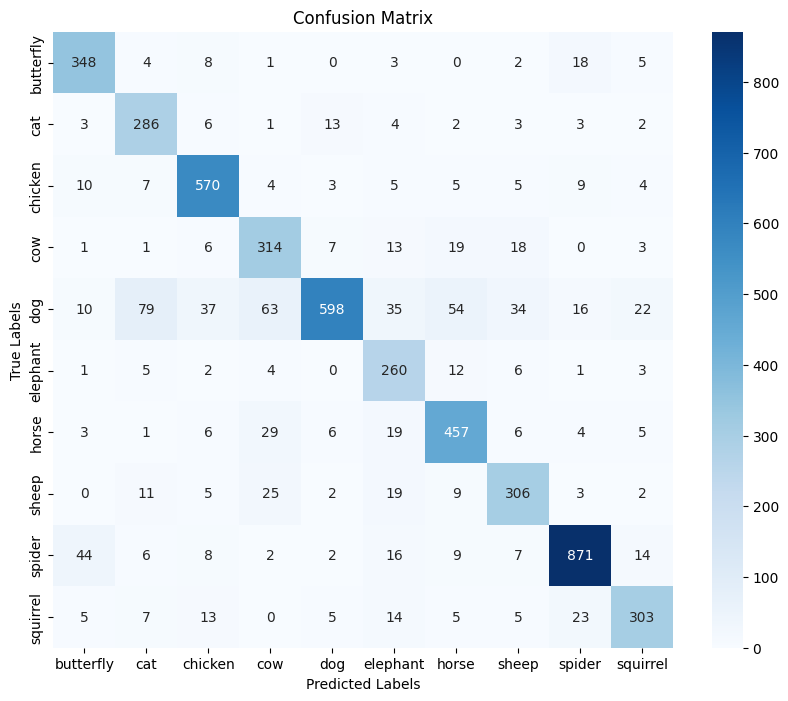

In [22]:
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

# Get the labels
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))


# Build the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

### 3.2 Accuracy and loss curves

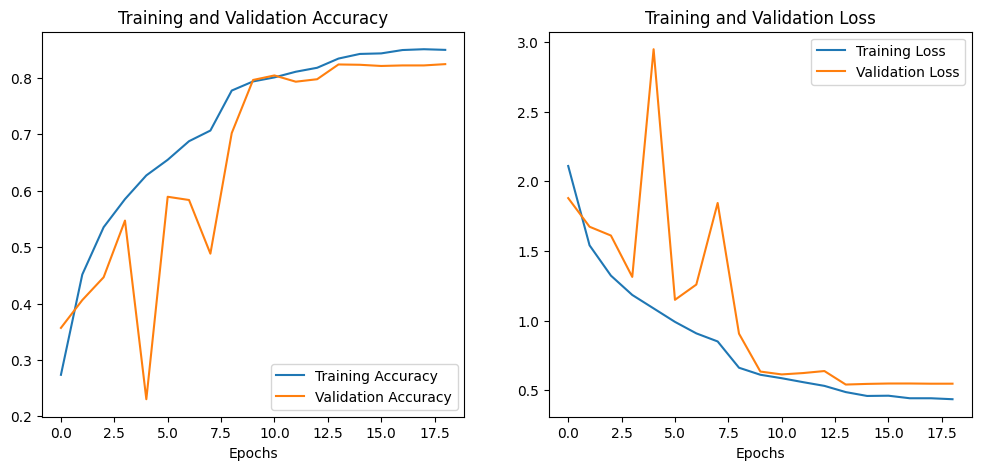

In [16]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.title("Training and Validation Accuracy")
plt.legend(loc="lower right")

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.title("Training and Validation Loss")
plt.legend(loc="upper right")

plt.show()

### 3.3 Precision, recall, F1 score

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))


              precision    recall  f1-score   support

   butterfly       0.82      0.89      0.86       389
         cat       0.70      0.89      0.78       323
     chicken       0.86      0.92      0.89       622
         cow       0.71      0.82      0.76       382
         dog       0.94      0.63      0.76       948
    elephant       0.67      0.88      0.76       294
       horse       0.80      0.85      0.82       536
       sheep       0.78      0.80      0.79       382
      spider       0.92      0.89      0.90       979
    squirrel       0.83      0.80      0.82       380

    accuracy                           0.82      5235
   macro avg       0.80      0.84      0.81      5235
weighted avg       0.84      0.82      0.82      5235



## 4. Transfer Learning

In [25]:
from tensorflow.keras.applications import mobilenet_v2, vgg16, inception_v3

# Create training and validation set again - no additional preprocessing
train_ds = tf.keras.utils.image_dataset_from_directory(
    **data_kwargs,
    subset="training"
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    **data_kwargs,
    subset="validation"
)


# Change depending on the selected model ('mobilenet', 'vgg16', or 'inception')
selected_model = "vgg16"

def preprocess_func(image, label):
    if selected_model == "mobilenet":
        image = mobilenet_v2.preprocess_input(image)
    elif selected_model == "vgg16":
        image = vgg16.preprocess_input(image)
    elif selected_model == "inception":
        image = inception_v3.preprocess_input(image)
    return image, label

# Map to training and validation datasets
train_ds_preprocessed = train_ds.map(preprocess_func)
val_ds_preprocessed = val_ds.map(preprocess_func)

Found 26179 files belonging to 10 classes.
Using 20944 files for training.
Found 26179 files belonging to 10 classes.
Using 5235 files for validation.


In [26]:
# Load the Base Model
if selected_model == "mobilenet":
    base = mobilenet_v2.MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
elif selected_model == "vgg16":
    base = vgg16.VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
elif selected_model == "inception":
    base = inception_v3.InceptionV3(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze the base
base.trainable = False

# Add custom head
model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(10, activation="softmax")
])

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849,610 (56.65 MB)

 Trainable params: 134,410 (525.04 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [ ]:
# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Fit the model
history = model.fit(
    train_ds_preprocessed,
    validation_data=val_ds_preprocessed,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

# Save the model
model.save(f"animal_classifier_{selected_model}.keras")

Epoch 1/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 208s 291ms/step - accuracy: 0.5191 - loss: 1.5814 - val_accuracy: 0.9253 - val_loss: 0.2784
Epoch 2/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 167s 254ms/step - accuracy: 0.8920 - loss: 0.3475 - val_accuracy: 0.9490 - val_loss: 0.1954
Epoch 3/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 167s 254ms/step - accuracy: 0.9228 - loss: 0.2521 - val_accuracy: 0.9545 - val_loss: 0.1653
Epoch 4/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 166s 254ms/step - accuracy: 0.9389 - loss: 0.2015 - val_accuracy: 0.9603 - val_loss: 0.1427
Epoch 5/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 167s 254ms/step - accuracy: 0.9461 - loss: 0.1772 - val_accuracy: 0.9620 - val_loss: 0.1341
Epoch 6/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 166s 254ms/step - accuracy: 0.9503 - loss: 0.1553 - val_accuracy: 0.9637 - val_loss: 0.1278
Epoch 7/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 204s 256ms/step - accuracy: 0.9574 - loss: 0.1351 - val_accuracy: 0.9660 - val_loss: 0.1207
Epoch 8/20
655/655 ━━━━━━━━━━━━━━━━━━━━ 166s 254ms/step - accuracy: 0.9600 -